## 🤖 Customer Segmentation with KMeans

This project segments customers based on purchasing behavior using KMeans clustering.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 📥 Data Loading

In [5]:
df = pd.read_csv("../data/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 🧹 Data Cleaning

In [8]:
df_clean = df[
    (df["CustomerID"].notna()) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]
df_clean = df_clean.copy()
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

## 🧠 Feature Engineering (Customer-Level Metrics)

In [9]:
customer_df = df_clean.groupby("CustomerID").agg({
    "Revenue": "sum",
    "InvoiceNo": "nunique",
    "Quantity": "sum"
}).reset_index()

In [10]:
customer_df.columns = [
    "CustomerID",
    "TotalRevenue",
    "NumPurchases",
    "TotalQuantity"
]

In [11]:
customer_df.head()

,CustomerID,TotalRevenue,NumPurchases,TotalQuantity
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


### Feature Selection

In [12]:
features = customer_df[[
    "TotalRevenue",
    "NumPurchases",
    "TotalQuantity"
]]

### Data Normalization

In [13]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

### Applying KMeans

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)

customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

In [18]:
customer_df.head()

,CustomerID,TotalRevenue,NumPurchases,TotalQuantity,Cluster
0,12346,77183.60,1,74215,1
1,12347,4310.00,7,2458,0
2,12348,1797.24,4,2341,0
3,12349,1757.55,1,631,0
4,12350,334.40,1,197,0


### Cluster Analysis

In [16]:
customer_df.groupby("Cluster").mean()

,CustomerID,TotalRevenue,NumPurchases,TotalQuantity
Cluster,,,,
0,15302.539565,1045.100231,2.966123,621.738625
1,15007.117647,65307.416471,61.235294,44177.235294
2,15268.470588,9294.429485,18.801471,5184.536765
3,16311.000000,209342.334000,76.400000,98458.800000


## 🔍 Key Insights

- High-value customers generate most revenue  
- Some customers buy frequently but spend less  
- Low-value customers represent a large portion of the base  

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

In [24]:
pca_df = pd.DataFrame(
    data=pca_features,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = customer_df["Cluster"]

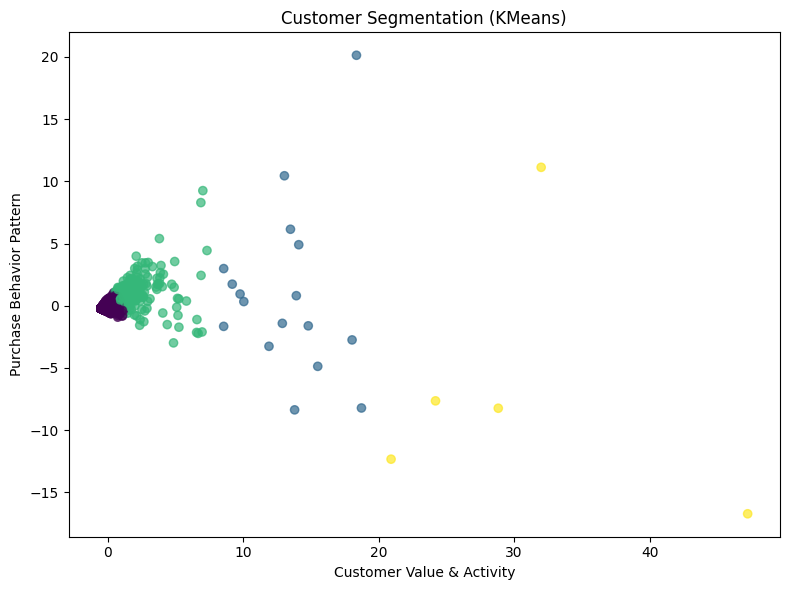

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segmentation (KMeans)")
plt.xlabel("Customer Value & Activity")
plt.ylabel("Purchase Behavior Pattern")

plt.tight_layout()
plt.savefig("../outputs/clusters.png")

plt.show()